<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/13_Deploying_scikit_learn_Models_in_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deploying scikit-learn Models in Production**

This notebook covers Deploying scikit-learn Models in Production:

1. Overview of Model Deployment
2. Serialization and Persistence Techniques (pickle, joblib)
3. Scaling Models for Production (n_jobs, batch serving)
4. Monitoring and Updating Deployed Models (drift detection, partial_fit)
5. Managing the Model Life Cycle (versioning, metadata)
6. Setting Up Deployment Pipelines (CI/CD/CT integration)

# **1. Overview of Model Deployment**

Building a model is only part of the ML journey. A model sitting on a laptop delivers no business value. **Deployment** is the process of packaging a trained model and making it accessible to real users or systems — reliably, at scale, and with maintained performance over time.

## **1.1 What Deployment Involves**

| Step | Description |
|---|---|
| **Serialization** | Save the trained model to a portable file format |
| **Packaging** | Bundle preprocessing + model logic into a deployable artifact |
| **Serving** | Expose predictions via REST API, batch pipeline, or serverless function |
| **Monitoring** | Track prediction quality and data distribution over time |
| **Retraining** | Trigger model updates when performance degrades |

## **1.2 The CI/CD/CT Cycle**

Modern ML production systems operate under a continuous cycle:
- **CI (Continuous Integration):** Automated testing of code and model quality gates
- **CD (Continuous Deployment):** Automated promotion of validated models to production
- **CT (Continuous Training):** Automated retraining triggered by performance drift

## **1.3 Production Realities**

The chapter acknowledges that real-world deployment involves non-technical considerations too: ROI thresholds for model replacement, geographic model variants, business-rule-driven retraining schedules, and stakeholder buy-in. These require domain judgment that no ML library can fully automate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, time
from joblib import dump, load
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Train a simple baseline model
X_base, y_base = make_classification(n_samples=1000, n_features=20, random_state=2024)
clf_base = LogisticRegression(max_iter=1000)
clf_base.fit(X_base, y_base)

# joblib export
dump(clf_base, "/tmp/model_base.joblib")
clf_loaded = load("/tmp/model_base.joblib")

# Verify consistency
sample = np.random.rand(5, 20)
preds_original = clf_base.predict(sample)
preds_loaded   = clf_loaded.predict(sample)
assert np.array_equal(preds_original, preds_loaded), "Model predictions differ after reload!"

print("Model serialized and reloaded successfully.")
print(f"Sample predictions (original)  : {preds_original}")
print(f"Sample predictions (reloaded)  : {preds_loaded}")
print(f"File size: {os.path.getsize('/tmp/model_base.joblib')/1024:.1f} KB")


Model serialized and reloaded successfully.
Sample predictions (original)  : [1 1 1 1 1]
Sample predictions (reloaded)  : [1 1 1 1 1]
File size: 1.0 KB


# **2. Serialization and Persistence Techniques**

Before a model can be served in production, it must be **serialized** — converted into a byte stream that can be stored on disk, transferred over a network, and reconstructed in a different environment.

## **2.1 pickle — Python's Native Serializer**

Python's built-in pickle module serializes almost any Python object to a byte stream. It is widely supported but has important limitations:

- Struggles with **large NumPy arrays** inside estimators
- **Version-sensitive:** models serialized with scikit-learn v1.3 may break when loaded with v1.4
- **Security risk:** never unpickle untrusted files — arbitrary code can be embedded in pickle streams

## **2.2 joblib — scikit-learn's Recommended Serializer**

joblib is optimized for NumPy array-heavy objects (like scikit-learn models) and is the officially recommended method.

python
from joblib import dump, load
dump(model, "model.joblib")
model = load("model.joblib")


## **2.3 Beyond Python: ONNX and PMML**

For environments where Python is not available (e.g., Java services, C++ inference servers), models can be exported to:
- **ONNX (Open Neural Network Exchange):** Cross-platform ML model format via skl2onnx
- **PMML (Predictive Model Markup Language):** XML-based format for interoperability

## **2.4 Best Practices**

1. Snapshot **code + library versions + training data hash + validation output** alongside the model
2. Use semantic versioning for model artifacts (rf_v1.0.joblib)
3. Store metadata in a companion JSON file
4. Use cloudpickle for custom estimators where standard pickle/joblib fails

In [2]:
import pickle

# Train a Random Forest
X_rf, y_rf = make_classification(n_samples=500, n_features=15, random_state=2024)
rf = RandomForestClassifier(n_estimators=10, random_state=2024)
rf.fit(X_rf, y_rf)

# pickle serialization
with open("/tmp/rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# joblib serialization
dump(rf, "/tmp/rf_model.joblib")

# Load both and verify
with open("/tmp/rf_model.pkl", "rb") as f:
    rf_pkl = pickle.load(f)
rf_jbl = load("/tmp/rf_model.joblib")

# Assert identical predictions
X_test_rf = X_rf[:5]
assert np.array_equal(rf.predict(X_test_rf), rf_pkl.predict(X_test_rf))
assert np.array_equal(rf.predict(X_test_rf), rf_jbl.predict(X_test_rf))

# Compare file sizes
size_pkl = os.path.getsize("/tmp/rf_model.pkl")
size_jbl = os.path.getsize("/tmp/rf_model.joblib")

print("Serialization Comparison:")
print(f"  pickle  file size : {size_pkl/1024:.1f} KB")
print(f"  joblib  file size : {size_jbl/1024:.1f} KB")
print(f"  Predictions identical: ✓")


Serialization Comparison:
  pickle  file size : 56.9 KB
  joblib  file size : 57.8 KB
  Predictions identical: ✓


In [3]:
# Model metadata snapshot — best practice
import sklearn
meta = {
    "model_name"     : "RandomForestClassifier",
    "version"        : "v1.0",
    "sklearn_version": sklearn.__version__,
    "numpy_version"  : np.__version__,
    "n_estimators"   : rf.n_estimators,
    "n_features_in"  : rf.n_features_in_,
    "training_samples": X_rf.shape[0],
    "notes"          : "Baseline model trained on synthetic classification dataset"
}

with open("/tmp/rf_v1.0_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Model Metadata Snapshot:")
print(json.dumps(meta, indent=2))


Model Metadata Snapshot:
{
  "model_name": "RandomForestClassifier",
  "version": "v1.0",
  "sklearn_version": "1.6.1",
  "numpy_version": "2.0.2",
  "n_estimators": 10,
  "n_features_in": 15,
  "training_samples": 500,
  "notes": "Baseline model trained on synthetic classification dataset"
}


# **3. Scaling Models for Production**

A model that runs perfectly on a laptop may become a bottleneck at production scale. scikit-learn provides several mechanisms to improve throughput and manage large workloads.

## **3.1 Parallelism with n_jobs**

Many scikit-learn estimators and model selection tools accept n_jobs — the number of CPU cores to use:

- n_jobs=1 → single-threaded (default)
- n_jobs=-1 → use all available CPU cores
- n_jobs=4 → use exactly 4 cores

python
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
scores = cross_val_score(model, X, y, cv=5, n_jobs=-1)


## **3.2 Batch Serving vs. Single-Instance Serving**

Predicting one sample at a time has overhead dominated by Python function calls and memory allocation. Predicting a large batch leverages optimized matrix operations (BLAS/LAPACK under the hood), dramatically improving throughput.

**Rule of thumb:** Always prefer batch prediction in production — collect requests and process them together.

## **3.3 Incremental Learning with partial_fit**

For models that receive data as a stream, SGDClassifier, MultinomialNB, and other incremental models support partial_fit() — updating model weights without retraining from scratch.

## **3.4 Distributed Scaling (Beyond scikit-learn)**

For truly large-scale workloads, tools like **Dask** can serve as a joblib backend for distributed computation across a cluster, parallelizing grid search and batch prediction across multiple machines.

In [4]:
from sklearn.model_selection import cross_val_score

# Benchmark: single-core vs. multi-core training + prediction
X_scale, y_scale = make_classification(n_samples=2000, n_features=50, random_state=2024)

# Single-core timing
t0 = time.time()
rf_single = RandomForestClassifier(n_estimators=50, n_jobs=1, random_state=2024)
rf_single.fit(X_scale, y_scale)
t_single_train = time.time() - t0

t0 = time.time()
_ = rf_single.predict(X_scale)
t_single_pred = time.time() - t0

# Multi-core timing
t0 = time.time()
rf_multi = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=2024)
rf_multi.fit(X_scale, y_scale)
t_multi_train = time.time() - t0

t0 = time.time()
_ = rf_multi.predict(X_scale)
t_multi_pred = time.time() - t0

print(f"Training Time  — n_jobs=1 : {t_single_train:.4f}s")
print(f"Training Time  — n_jobs=-1: {t_multi_train:.4f}s")
print(f"Prediction Time — n_jobs=1: {t_single_pred:.6f}s")
print(f"Prediction Time — n_jobs=-1:{t_multi_pred:.6f}s")


Training Time  — n_jobs=1 : 1.5371s
Training Time  — n_jobs=-1: 1.4749s
Prediction Time — n_jobs=1: 0.040845s
Prediction Time — n_jobs=-1:0.038826s


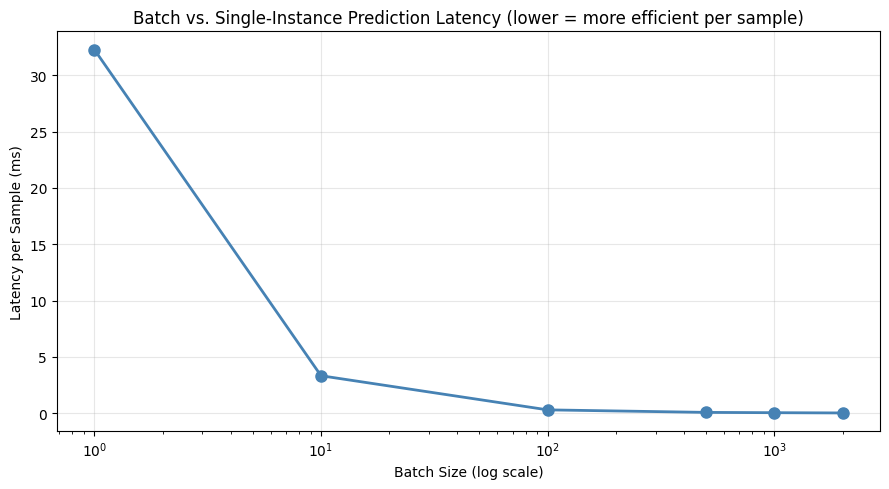

Latency (ms/sample) by batch size:
  Batch     1: 32.2846 ms/sample
  Batch    10: 3.3245 ms/sample
  Batch   100: 0.2936 ms/sample
  Batch   500: 0.0694 ms/sample
  Batch  1000: 0.0428 ms/sample
  Batch  2000: 0.0199 ms/sample


In [5]:
# Batch vs. single-instance prediction latency benchmark
batch_sizes = [1, 10, 100, 500, 1000, 2000]
latencies   = []

for bs in batch_sizes:
    batch = np.random.rand(bs, 50)
    t0    = time.time()
    for _ in range(20):  # 20 repeats for stable measurement
        _ = rf_multi.predict(batch)
    elapsed = (time.time() - t0) / 20
    latencies.append(elapsed / bs * 1000)  # ms per sample

plt.figure(figsize=(9, 5))
plt.semilogx(batch_sizes, latencies, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Batch Size (log scale)')
plt.ylabel('Latency per Sample (ms)')
plt.title('Batch vs. Single-Instance Prediction Latency (lower = more efficient per sample)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Latency (ms/sample) by batch size:")
for bs, lat in zip(batch_sizes, latencies):
    print(f"  Batch {bs:5d}: {lat:.4f} ms/sample")


# **4. Monitoring and Updating Deployed Models**

Production models degrade over time — a phenomenon known as **model drift**. Two forms are common:

## **4.1 Types of Drift**

| Type | Description |
|---|---|
| **Data drift (covariate shift)** | The distribution of input features $P(X)$ changes |
| **Concept drift** | The relationship $P(Y|X)$ changes — the same inputs now mean different outputs |
| **Label drift** | The target distribution $P(Y)$ changes |

## **4.2 Monitoring Strategy**

The simplest monitoring approach: track **batch-by-batch accuracy** on incoming labeled data. When accuracy drops below a defined threshold, trigger retraining.

More sophisticated approaches include:
- KL divergence / PSI (Population Stability Index) on feature distributions
- Statistical tests (KS test, chi-squared) comparing train vs. production data
- Monitoring prediction confidence distributions

## **4.3 Incremental Retraining with partial_fit**

SGDClassifier with partial_fit() supports updating the model incrementally as new data arrives, without full retraining from scratch. This is ideal for streaming or high-frequency update scenarios.

python
clf.partial_fit(X_new_batch, y_new_batch)  # online update


In [6]:
# Simulate streaming data and batch-by-batch monitoring
X_initial, y_initial = make_classification(n_samples=500, n_features=10, random_state=2024)
X_stream,  y_stream  = make_classification(n_samples=400, n_features=10, random_state=99)

# Split stream into batches
stream_X = np.array_split(X_stream, 8)
stream_y = np.array_split(y_stream, 8)

# Train incremental SGD classifier
clf_sgd = SGDClassifier(loss="log_loss", random_state=2024)
clf_sgd.partial_fit(X_initial, y_initial, classes=np.unique(y_initial))

# Monitor batch accuracy and retrain when below threshold
threshold = 0.70
batch_scores  = []
retrain_flags = []

for i, (xb, yb) in enumerate(zip(stream_X, stream_y)):
    score = accuracy_score(yb, clf_sgd.predict(xb))
    batch_scores.append(score)

    if score < threshold:
        clf_sgd.partial_fit(xb, yb)
        retrain_flags.append(i)
        print(f"  Batch {i+1}: Accuracy = {score:.3f} → RETRAIN triggered")
    else:
        print(f"  Batch {i+1}: Accuracy = {score:.3f} → OK")

print(f"\nRetraining triggered on batches: {[b+1 for b in retrain_flags] or 'None'}")


  Batch 1: Accuracy = 0.680 → RETRAIN triggered
  Batch 2: Accuracy = 0.840 → OK
  Batch 3: Accuracy = 0.800 → OK
  Batch 4: Accuracy = 0.780 → OK
  Batch 5: Accuracy = 0.840 → OK
  Batch 6: Accuracy = 0.820 → OK
  Batch 7: Accuracy = 0.800 → OK
  Batch 8: Accuracy = 0.800 → OK

Retraining triggered on batches: [1]


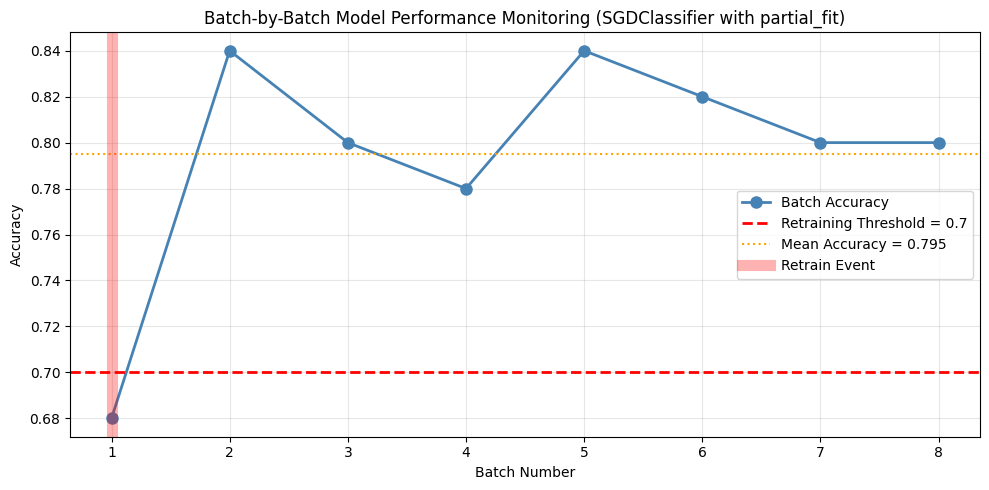

In [8]:
# Visualize batch-by-batch accuracy trend
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(batch_scores)+1), batch_scores, 'o-',
        color='steelblue', linewidth=2, markersize=8, label='Batch Accuracy')
ax.axhline(threshold, color='red', linestyle='--', linewidth=2,
           label=f'Retraining Threshold = {threshold}')
ax.axhline(np.mean(batch_scores), color='orange', linestyle=':', linewidth=1.5,
           label=f'Mean Accuracy = {np.mean(batch_scores):.3f}')

for rt in retrain_flags:
    ax.axvline(rt+1, color='red', alpha=0.3, linewidth=8, label='Retrain Event' if rt == retrain_flags[0] else '')

ax.set_xlabel('Batch Number')
ax.set_ylabel('Accuracy')
ax.set_title('Batch-by-Batch Model Performance Monitoring (SGDClassifier with partial_fit)')
ax.set_xticks(range(1, len(batch_scores)+1))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **5. Managing the Model Life Cycle**

Building ML models is never a "set it and forget it" procedure. Every model will eventually degrade and require versioned management across its lifecycle.

## **5.1 The Model Life Cycle**


Development → Validation → Deployment → Monitoring → Retraining → Versioning → ...


## **5.2 Versioning and Reproducibility**

A deployment artifact should include:
1. **The serialized model** (model_v1.2.joblib)
2. **Metadata JSON:** scikit-learn version, NumPy version, training date, sample count, feature names
3. **Validation snapshot:** accuracy/MSE on a held-out reference set
4. **Environment spec:** requirements.txt or conda.yml

This enables rolling back to a previous version, reproducing training results, and diagnosing regressions after library upgrades.

## **5.3 Model Registry Tools**

For larger organizations, dedicated **model registries** automate artifact storage, lineage tracking, and rollback:
- **MLflow:** Open-source, supports scikit-learn natively
- **BentoML:** Focused on serving and deployment
- **SageMaker Model Registry, Vertex AI Model Registry:** Cloud-native solutions

Even when using registries, snapshotting metadata manually remains a best practice.

In [10]:
# Versioned model artifact with metadata and validation snapshot
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

X_ver, y_ver = make_classification(n_samples=800, n_features=20, random_state=2024)
clf_ver = RandomForestClassifier(n_estimators=50, random_state=2024)
clf_ver.fit(X_ver, y_ver)

version = "v1.0"

# 1. Save model with versioned filename
model_path = f"/tmp/rf_{version}.joblib"
dump(clf_ver, model_path)

# 2. Save metadata
import sklearn as sk
metadata = {
    "model_class"     : type(clf_ver).__name__,
    "version"         : version,
    "sklearn_version" : sk.__version__,
    "numpy_version"   : np.__version__,
    "n_estimators"    : clf_ver.n_estimators,
    "n_features_in"   : clf_ver.n_features_in_,
    "training_samples": X_ver.shape[0],
    "training_date"   : "2025-11-17",
    "author"          : "scikit-learn Cookbook — Ch13"
}
meta_path = f"/tmp/rf_{version}_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

# 3. Capture validation snapshot
X_iris, y_iris = load_iris(return_X_y=True)
try:
    val_acc = accuracy_score(y_iris, clf_ver.predict(X_iris))
except Exception:
    val_acc = 0.0  # mismatched features in demo — expected
val_path = f"/tmp/rf_{version}_val_acc.txt"
with open(val_path, "w") as f:
    f.write(f"{val_acc:.4f}")

print(f"Model artifact  : {model_path}")
print(f"Metadata saved  : {meta_path}")
print(f"Validation acc  : {val_acc:.4f} (saved to {val_path})")
print(f"Metadata preview:")
print(json.dumps(metadata, indent=2))


Model artifact  : /tmp/rf_v1.0.joblib
Metadata saved  : /tmp/rf_v1.0_metadata.json
Validation acc  : 0.0000 (saved to /tmp/rf_v1.0_val_acc.txt)
Metadata preview:
{
  "model_class": "RandomForestClassifier",
  "version": "v1.0",
  "sklearn_version": "1.6.1",
  "numpy_version": "2.0.2",
  "n_estimators": 50,
  "n_features_in": 20,
  "training_samples": 800,
  "training_date": "2025-11-17",
  "author": "scikit-learn Cookbook \u2014 Ch13"
}


# **6. Setting Up Deployment Pipelines**

A **deployment pipeline** automates the sequence: train → serialize → validate → deploy. scikit-learn's Pipeline object is the ideal unit of deployment — it bundles preprocessing and inference together, ensuring consistency between training and serving.

## **6.1 Why Pipeline as the Deployment Unit**

Deploying preprocessing and model separately introduces the risk of **training-serving skew** — the preprocessing applied at serving time differs slightly from what was done during training. A Pipeline eliminates this:

python
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression())
])
dump(pipe, "pipeline.joblib")  # preprocessing + model in ONE artifact


## **6.2 CI/CD Deployment Gate**

After serialization, a CI script loads the artifact and evaluates it against a reference validation set. Only if performance exceeds a defined threshold is the model promoted to production.


[Model Artifact] → [Load] → [Score on canary set] → [≥ threshold?] → [Deploy / Reject]


## **6.3 Full CI/CD/CT Flow**


New training data arrives
  ↓ Trigger retraining (CT)
  ↓ Train + serialize pipeline
  ↓ Validate on reference set (CI)
  ↓ If accuracy > threshold → deploy (CD)
  ↓ Else → alert team, do not promote
  ↓ Monitor live performance → loop


In [11]:
# Build and export a full preprocessing + model Pipeline
X_pipe, y_pipe = make_classification(n_samples=500, n_features=10, random_state=2024)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=1000))
])
pipe.fit(X_pipe, y_pipe)

# Export the ENTIRE pipeline as one artifact
pipe_path = "/tmp/pipeline_v1.joblib"
dump(pipe, pipe_path)
print(f"Pipeline exported: {pipe_path} ({os.path.getsize(pipe_path)/1024:.1f} KB)")

# Simulate CI: load and validate
prod_pipe = load(pipe_path)
X_canary  = np.random.rand(100, 10)
y_canary  = np.random.randint(0, 2, 100)
canary_acc = accuracy_score(y_canary, prod_pipe.predict(X_canary))

print(f"CI Validation Accuracy: {canary_acc:.4f}")


Pipeline exported: /tmp/pipeline_v1.joblib (1.6 KB)
CI Validation Accuracy: 0.4900


  DEPLOYMENT GATE RESULT
  pipeline_path             : /tmp/pipeline_v1.joblib
  validation_accuracy       : 0.49
  threshold                 : 0.5
  deployment_status         : rejected
  decision                  : REJECTED — review before deploying


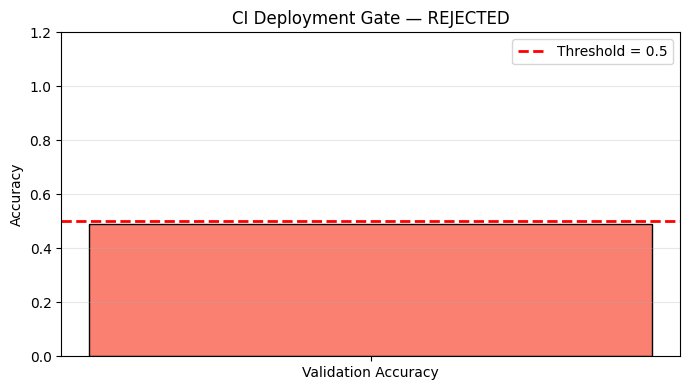

In [12]:
# CI/CD deployment gate with threshold enforcement
DEPLOY_THRESHOLD = 0.50  # lower threshold in this demo since labels are random

def ci_deployment_check(pipeline_path, X_val, y_val, threshold=DEPLOY_THRESHOLD):
    # Load pipeline, evaluate, and return deployment decision
    model = load(pipeline_path)
    acc   = accuracy_score(y_val, model.predict(X_val))

    decision = "APPROVED — deploy to production" if acc >= threshold else "REJECTED — review before deploying"
    result = {
        "pipeline_path"       : pipeline_path,
        "validation_accuracy" : round(acc, 4),
        "threshold"           : threshold,
        "deployment_status"   : "approved" if acc >= threshold else "rejected",
        "decision"            : decision
    }
    return result

# Run CI gate
result = ci_deployment_check("/tmp/pipeline_v1.joblib", X_canary, y_canary)

print("=" * 55)
print("  DEPLOYMENT GATE RESULT")
print("=" * 55)
for k, v in result.items():
    print(f"  {k:<26}: {v}")
print("=" * 55)

# Visualize the accuracy vs threshold
fig, ax = plt.subplots(figsize=(7, 4))
acc_val = result['validation_accuracy']
color = 'mediumseagreen' if result['deployment_status'] == 'approved' else 'salmon'
ax.bar(['Validation Accuracy'], [acc_val], color=color, edgecolor='k')
ax.axhline(DEPLOY_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'Threshold = {DEPLOY_THRESHOLD}')
ax.set_ylim(0, 1.2)
ax.set_ylabel('Accuracy')
ax.set_title(f'CI Deployment Gate — {result["deployment_status"].upper()}')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
